# TP4 : Factorisation en matrices non-négatives (NMF)

Importez les bibliothèques suivantes.

In [3]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

Les TPs précédents portaient sur le K-clustering et la PCA. Le présent TP utilisant les résultats de ces dernier, voici une cellule important les classes `KMeans` (**[documentation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)**) et `PCA` (**[documentation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)**) de la bibliothèque `sklearn`. Regardez bien les documentations. Le nom des attributs et méthodes n'est pas nécessairement le même que dans les classes que nous avons nous même définies. 

In [4]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

def accuracy(labels):
    ct = pd.crosstab(labels, y)
    row_maxes = ct.max(axis=1)
    sum_of_maxes = row_maxes.sum()
    total_elements = ct.values.sum()
    proportion = sum_of_maxes / total_elements
    return proportion

Nous avons également besoin de la fonction affichant une image ou une liste d'images (au format 784 pixels).

In [6]:
def display_image(source):
    if len(source) == 784:
        images = [source]
    elif len(source[0]) == 784:
        images = source
    else:
        print("error")
    
    l = len(images)
    c = math.ceil(l / 3)
    fig, axes = plt.subplots(c, 3, figsize=(12, 5))

    for i, ax in enumerate(axes.flat):
        if i < l:
            img = images[i].reshape(28, 28)
            ax.imshow(img, cmap='gray')
            ax.set_title(f"Image {i + 1}")
        ax.axis('off')

Enfin, importez les jeux de données.

In [7]:
## from google.colab import files
## data_to_load1 = files.upload()
## import io
## df_pixels = pd.read_csv(io.BytesIO(data_to_load1['pixels.csv']))

df_pixels = pd.read_csv("pixels.csv")
X = df_pixels.to_numpy(dtype="float32")
df_label = pd.read_csv("labels.csv")
y = df_label["label"].values

L'objectif de ce TP va consister en la définition progressive (par Monkey-Patching) d'une classe `MyNMF` implémentant l'algorithme de NMF de Lee and Seung.

In [8]:
class MyNMF:
    def __init__(self, n_components, max_iter=500, tol=0.0005):
        self.n_components = n_components
        self.max_iter = max_iter
        self.tol = tol
        
        self.components = None 
        self.reconstruction_err = []

print("Classe initialisée.")

Classe initialisée.


## Exercice 1 

Construisez une fonction `compute_loss(data,W,H)` renvoyant la distance entre matrice `data` et $W \cdot H$ (à l'aide de la norme de Frobenius).

In [1]:
def compute_loss(data,W,H):
    diff= np.linalg.norm(data - W@H)
    return diff

## Exercice 2 

Pour commencer l'implémentation de la classe, construisez une fonction `initialize_matrices(data,n_components)` renvoyant deux matrices `W,H` aux correctes dimensions initialisant l'algorithme de Lee et Seung avec des nombres positifs choisis aléatoirement.

In [9]:
def initialize_matrices(data,n_components):
    moy_x = np.mean(data,axis=1)
    W=np.random.rand(data.shape[0],n_components)*moy_x[:,np.newaxis]
    H=np.random.rand(n_components,data.shape[1])
    return W,H

## Exercice 3 

Nous allons maintenant définir une fonction `update_matrices(data, W, H, epsilon=1e-9)` renvoyant deux matrices `W,H` après une itération de l'algorithme de Lee et Seung. Le gros du travail va être de traduire la définition par élément de l'algorithme en termes matriciels (PAS DE BOUCLE FOR). Le terme `epsilon` a vocation a être ajouté aux dénominateurs afin d'éviter la division par 0.

In [10]:
def update_matrices(data,W,H,epsilon=1e-9):
    W = W * (data @ H.T) / ((W @ (H @ H.T)) + epsilon)
    H = H * (W.T @ data) / (((W.T @ W) @ H) + epsilon)
    return W,H

## Exercice 4

Nous allons maintenant construire la classe par Monkey-Patching.

1. Construisez une fonction `fit_transform(self, data)` implémentant la totalité de l'algorithme de Lee et Seung à l'aide des fonctions précedemments définies. Cette fonction renvoie `W` après optimisation et stocke `H` dans `self.components`. À chaque étape, on calcule l'erreur et on l'ajoute à la liste `self.reconstruction_err`. L'algorithme s'arrête lorsque le taux de variation de l'erreur passe sous le seuil de tolérance ou lorsqu'on atteint le nombre maximal d'itérations. Assignez la fonction à la classe `MyNMF`.

In [11]:
def fit_transform(self, data):
    W, self.components = initialize_matrices(data, self.n_components)
    
    for i in range(self.max_iter):
        W, self.components = update_matrices(data, W, self.components)
        loss = compute_loss(data,W,self.components)
        self.reconstruction_err.append(loss)
        if i > 2 and abs((self.reconstruction_err[-2]-self.reconstruction_err[-1])/ self.reconstruction_err[-2]) < self.tol:
            print(f"Convergence atteinte à {i}")
            break
            
    return W

MyNMF.fit_transform = fit_transform

2. Construisez une fonction `transform(self, data)` projettant une matrice `data` dans l'espace de la NMF. Construisez également une fonction `inverse_transform(self, data)` reconstruisant une matrice de données de l'espace de la NMF dans l'espace initial. Assignez lesfonctions à la classe `MyNMF`.

In [12]:
def transform(self, data):
    W = np.random.rand(data.shape[0], self.n_components)
    
    for i in range(self.max_iter):
        numer_W = np.dot(data, self.components.T)
        denom_W = np.dot(W, np.dot(self.components, self.components.T)) + 1e-9
        W = W * (numer_W / denom_W)
        
    return W

def inverse_transform(self, data):
    return np.dot(data, self.components)

MyNMF.transform = transform
MyNMF.inverse_transform = inverse_transform

## Exercice 5

Il est maintenant temps d'appliquer notre classe à nos données.

1. Créez une instance de la classe `MyNMF` afin de faire une NMF sur nos données (`X`) avec 6 composantes. Affichez les images correspondants aux 6 composantes.

Convergence atteinte à 75


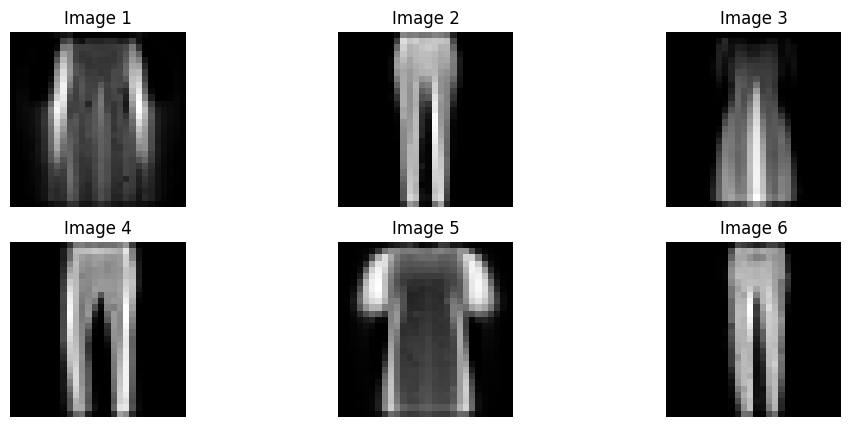

In [13]:
my_nmf = MyNMF(n_components=6)
C = my_nmf.fit_transform(X)

display_image(my_nmf.components)

2. Choisissez une image dans nos données. Affichez là avec ses compressions (projection puis reconstruction) après une NMF avec $i$ composantes, pour $i$ prenant les valeurs 3, 5, 10, 50 et 100.

Convergence atteinte à 72
Convergence atteinte à 64
Convergence atteinte à 104
Convergence atteinte à 167
Convergence atteinte à 220


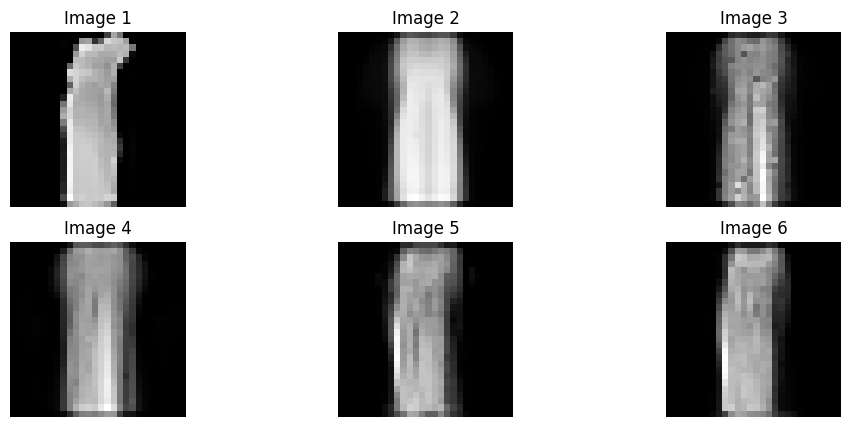

In [14]:
index = 245
images = [X[index]]
for i in [3,5,10,50,100]:
    my_nmf = MyNMF(n_components=i)
    V = my_nmf.fit_transform(X)
    inverse_im = my_nmf.inverse_transform(V)[index]
    images.append(inverse_im)
display_image(images)

2. Faites la même chose avec une PCA.

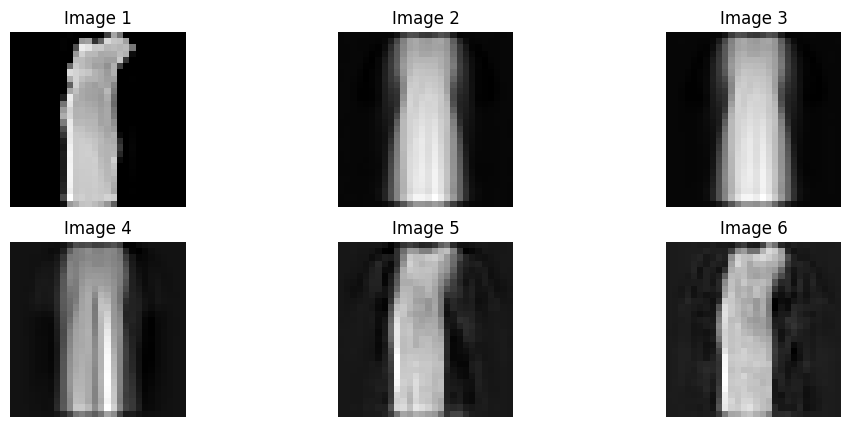

In [15]:
index = 245
images = [X[index]]
for i in [3,5,10,50,100]:
    my_pca = PCA(n_components=i)
    V = my_pca.fit_transform(X)
    inverse_im = my_pca.inverse_transform(V)[index]
    images.append(inverse_im)
display_image(images)

## Exercice 6

1. Utilisez la classe `MyNMF` pour projeter `X` sur deux dimensions. Visualisez le résultat dans un nuage de points avec `plt.scatter` (**[documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html#matplotlib.pyplot.scatter)**).

Convergence atteinte à 40


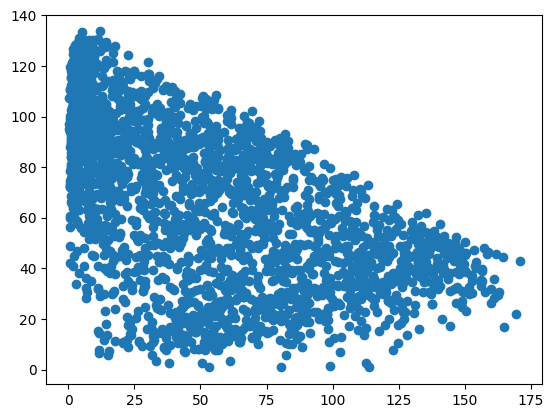

In [16]:
my_nmf = MyNMF(n_components=2)
proj = my_nmf.fit_transform(X)
plt.scatter(proj[:,0],proj[:,1])
plt.show()

2. Dans ce nuage de points, colorez chaque point en fonction de son véritable label (le vecteur de labels est `y`).

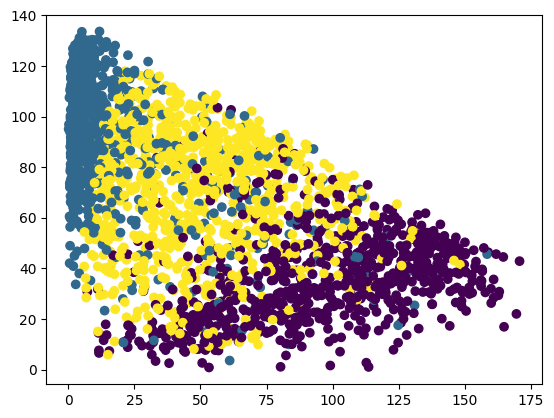

In [17]:
plt.scatter(proj[:,0],proj[:,1],c = y)
plt.show()

3. Changez la couleur des points pour qu'ils soient colorés en fonction de leur classification par un K-clustering de `X` avec 3 clusters. Affichez les images correspondants aux centroïdes. Affichez également la précision des labels obtenus.

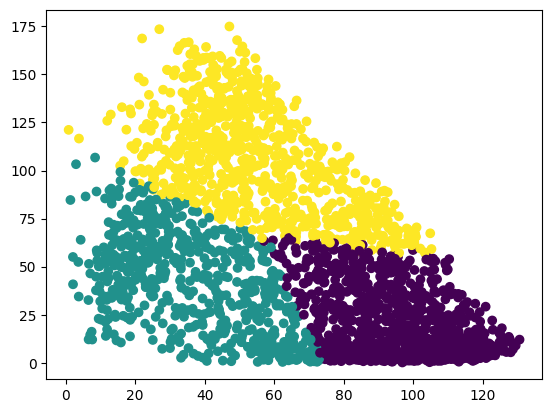

0.5688362919132149


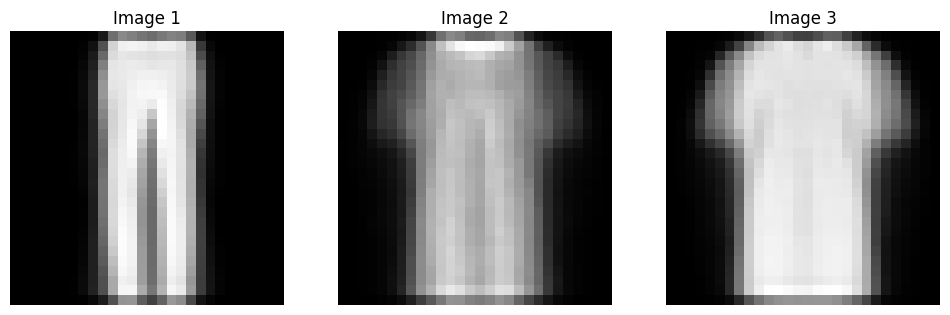

In [ ]:
my_km = KMeans(n_clusters=3)
my_km.fit(X)
plt.scatter(proj[:,0],proj[:,1],c = my_km.labels_)
plt.show()
display_image(my_km.cluster_centers_)
print(accuracy(my_km.labels_))

4. Enfin, changez la couleur des points pour qu'ils soient colorés en fonction de leur classification par un K-clustering de la projection NMF de `X` en 2 dimensions, avec 3 clusters. Affichez les images correspondants aux centroïdes ainsi que la précision des labels obtenus.

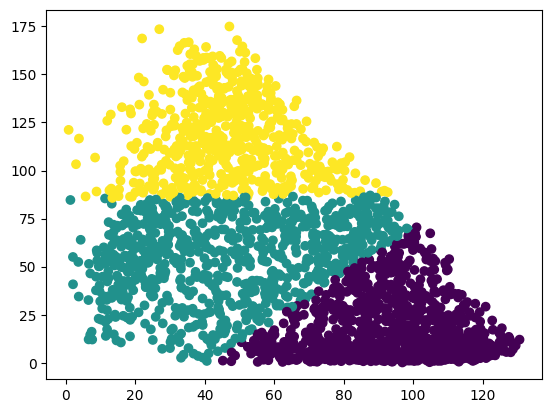

0.644181459566075


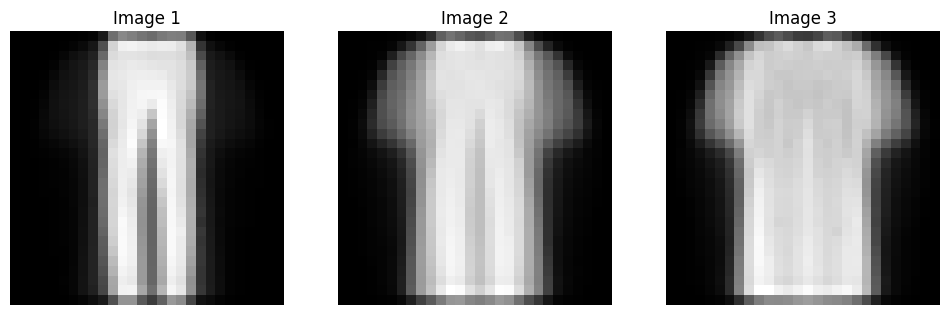

In [ ]:
my_km = KMeans(n_clusters=3)
my_km.fit(proj)
plt.scatter(proj[:,0],proj[:,1],c = my_km.labels_)
plt.show()
display_image(my_nmf.inverse_transform(my_km.cluster_centers_))
print(accuracy(my_km.labels_))

## Exercice 7

1. Dessinez un graphe calculant la précision (`accuracy`) des labels obtenus par un K-clusterings de la projection NMF de `X` avec $i$ composantes avec 3 clusters, pour $i$ allant de 5 à 40 avec un pas de 5. Utilisez `plt.plot`. Faites le plusieurs fois, pour voir les différents minima locaux obtenus par optimisation. 

Convergence atteinte à 70
Convergence atteinte à 94
Convergence atteinte à 100
Convergence atteinte à 118
Convergence atteinte à 131
Convergence atteinte à 146
Convergence atteinte à 153
Convergence atteinte à 152


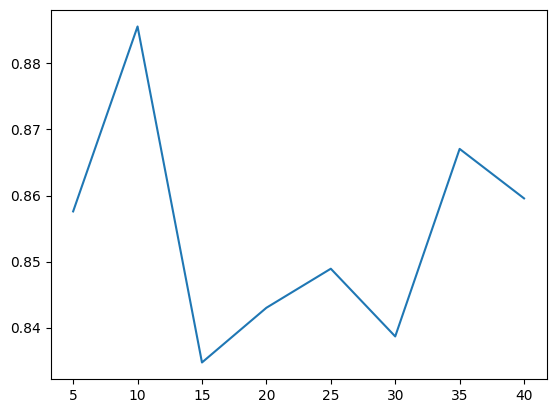

In [18]:
components = range(5,41,5)
accuracies = []
for n in components:
    my_nmf = MyNMF(n_components = n)
    proj = my_nmf.fit_transform(X)
    my_km = KMeans(n_clusters = 3)
    my_km.fit(proj)
    accuracies.append(accuracy(my_km.labels_))

plt.plot(components,accuracies)
plt.show()

2. Faîtes la même chose mais avec 20 clusters.

Convergence atteinte à 64
Convergence atteinte à 92
Convergence atteinte à 117
Convergence atteinte à 122
Convergence atteinte à 130
Convergence atteinte à 150
Convergence atteinte à 154
Convergence atteinte à 169


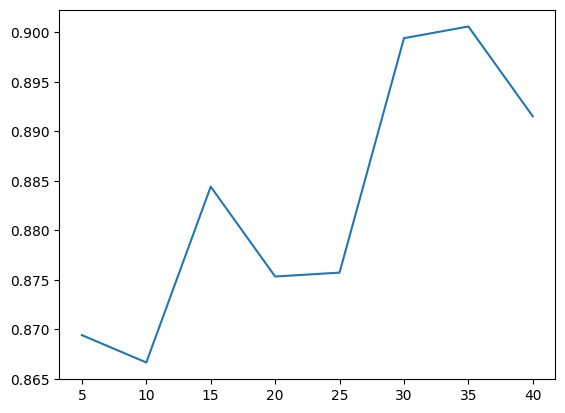

In [19]:
components = range(5,41,5)
accuracies = []
for n in components:
    my_nmf = MyNMF(n_components = n)
    X_proj = my_nmf.fit_transform(X)
    my_km = KMeans(n_clusters = 20)
    my_km.fit(X_proj)
    accuracies.append(accuracy(my_km.labels_))

plt.plot(components,accuracies)
plt.show()

3. Comment interprétez-vous les résultats ?

<!-- Les résultats montrent que la NMF atteint une précision maximale autour de 90% avec 20 composantes, tandis que le nombre de composantes optimal semble être moins critique que pour la PCA. La NMF capture mieux les caractéristiques locales et interprétables des images (parties de chiffres), ce qui la rend plus efficace pour la classification. En revanche, la PCA, étant une méthode linéaire globale, nécessite généralement plus de composantes pour obtenir des résultats comparables et produit des reconstructions moins nettes. -->

# Exercice 8

À l'aune de tous ces résultats, quelles différences faites vous entre la NMF et la PCA dans le cadre de notre analyse de données ?

In [ ]:
# La PCA cherche des composantes orthogonales qui expliquent la variance globalee positive ou negatives, 
# les engeinefaces ressemblent  a  des  formes fantomatiques globale interpretables(cherche avant tout à compresser l'information géométrique) car on soustrait et on additionne pour construire
# l'image 

# La NMF impose que tout soit positif W>0 et H>0, Cela force l'algorithme à apprendre une représentation par parties
# Les composantes ressemblent à des morceaux de chiffres (des barres, des boucles) que l'on additionne pour former l'image complète
# (capture mieux la structure des chiffres manuscrits)ce qui explique sa précision supérieure en classification